In [ ]:
from tensorflow.keras import layers, Model, Input

activation = 'relu'
#upconv_kernel_size = (3,3)
upconv_kernel_size = (2,2)

def Conv2DBlock(input_tensor, filters, kernel_size, USE_BN = True):
    '''
    Build a block of 2 Conv2D layers for U-Net encoder & decoder
    Return block output
    '''
    x = layers.Conv2D(filters, kernel_size, padding='same')(input_tensor)
    if USE_BN:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)

    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    if USE_BN:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def build_unet(input_shape, num_classes, num_filters = 16, kernel_size = 3):
    '''
    Build a U-Net model
    Return model
    '''
    x = inputs = Input(input_shape)

    # Build encoder
    e1 = Conv2DBlock(x, num_filters * 1, kernel_size)
    p1 = layers.MaxPooling2D(2, padding='same')(e1)

    e2 = Conv2DBlock(p1, num_filters * 2, kernel_size)
    p2 = layers.MaxPooling2D(2, padding='same')(e2)

    e3 = Conv2DBlock(p2, num_filters * 4, kernel_size)
    p3 = layers.MaxPooling2D(2, padding='same')(e3)

    e4 = Conv2DBlock(p3, num_filters * 8, kernel_size)
    p4 = layers.MaxPooling2D(2, padding='same')(e4)

    latent = Conv2DBlock(p4, num_filters * 16, kernel_size)

    # Build decoder
    d4 = layers.Conv2DTranspose(num_filters * 8, upconv_kernel_size, 2, padding='same', activation=activation)(latent)
    d4 = layers.concatenate([d4, e4])
    d4 = Conv2DBlock(d4, num_filters * 8, kernel_size)

    d3 = layers.Conv2DTranspose(num_filters * 4, upconv_kernel_size, 2, padding='same', activation=activation)(d4)
    d3 = layers.concatenate([d3, e3])
    d3 = Conv2DBlock(d3, num_filters * 4, kernel_size)

    d2 = layers.Conv2DTranspose(num_filters * 2, upconv_kernel_size, 2, padding='same', activation=activation)(d3)
    d2 = layers.concatenate([d2, e2])
    d2 = Conv2DBlock(d2, num_filters * 4, kernel_size)

    d1 = layers.Conv2DTranspose(num_filters * 1, upconv_kernel_size, 2, padding='same', activation=activation)(d2)
    d1 = layers.concatenate([d1, e1])
    d1 = Conv2DBlock(d1, num_filters * 1, kernel_size)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation = "softmax")(d1)
    model = Model(inputs, outputs, name='U-Net')
    return model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import utils
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/camvid_unet_semantic_segmentation-main/utils.py')

In [ ]:
import numpy as np
import cv2
import os
from tqdm import tqdm

base_dir = base_dir = os.getcwd()

def load_data_from_dir(set_df, resize=False, dim=(256, 256)):
    '''
    Load images and masks into two N-D arrays
    resize: Boolean
    dim = (width, height)
    '''
    data_dir = os.path.join(base_dir, 'data')
    image_stack = []
    mask_stack = []
    for img, msk in tqdm(zip(set_df['image'], set_df['mask'])):
        # load image
        image = cv2.imread(os.path.join(data_dir, img))# cv2 uses BGR order
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # BGR -> RGB
        # load mask
        mask = cv2.imread(os.path.join(data_dir, msk), cv2.IMREAD_GRAYSCALE) # load as grayscale image

        if resize:
            image = cv2.resize(image, dim, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, dim, interpolation=cv2.INTER_NEAREST)

        image_stack.append(image)
        mask_stack.append(mask)

    image_stack = np.array(image_stack) / 255.
    mask_stack = np.expand_dims(np.array(mask_stack), -1)

    return image_stack, mask_stack

color_dict = {
    0: (128, 128, 128),  # Sky
    1: (128, 0, 0),      # Building
    2: (192, 192, 128),  # Pole
    3: (128, 64, 128),   # Road
    4: (0, 0, 192),      # Sidewalk
    5: (128, 128, 0),    # Tree
    6: (192, 128, 128),  # SignSymbol
    7: (64, 64, 128),    # Fence
    8: (64, 0, 128),     # Car
    9: (64, 64, 0),      # Pedestrian
    10: (0, 128, 192),   # Bicyclist
    255: (0, 0, 0)       # Void
}

def convert_indexed_to_rgb_masks(masks):
    '''
    Convert a stack of indexed masks to RGB masks using the colormap of the original paper.
    '''
    masks_rgb = np.zeros((*masks.shape[0:3], 3), dtype=np.uint8)

    for i in range(11):
        color = color_dict[i]
        masks_rgb[(masks == i)[:,:,:,0]] = color

    return masks_rgb

def convert_indexed_to_rgb_mask(mask):
    '''
    Convert a single indexed masks to RGB masks using the colormap of the original paper.
    '''
    mask_rgb = np.zeros((*mask.shape[0:2], 3), dtype=np.uint8)

    for i in range(11):
        color = color_dict[i]
        mask_rgb[(mask == i)[:,:,0]] = color

    return mask_rgb



In [ ]:

#  Load the data

import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


## 1. Load data to memory

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

train_image_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/camvid_unet_semantic_segmentation-main/data/camvid_train.txt', header=None, sep=' ', names=['image', 'mask'])
val_image_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/camvid_unet_semantic_segmentation-main/data/camvid_val.txt', header=None, sep=' ', names=['image', 'mask'])
test_image_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/camvid_unet_semantic_segmentation-main/data/camvid_test.txt', header=None, sep=' ', names=['image', 'mask'])

classes = [
    'Sky', 'Building', 'Pole', 'Road', 'Pavement', 'Tree',
    'SignSymbol', 'Fence', 'Car', 'Pedestrian', 'Bicyclist',
    'Void'
    ]

n_class = 11  # ignore 'Void' (background) class
# print(len(train_image_df))
# print(train_image_df.head())  # Check filenames

base_dir = '/content/drive/MyDrive/Colab Notebooks/camvid_unet_semantic_segmentation-main'
# data_dir = os.path.join(base_dir, 'data')
# print(os.path.exists(os.path.join(data_dir, train_image_df['image'][0])))  # Test first image path

image_dim = (224, 224)  # same as vgg-16
train_images, train_masks = load_data_from_dir(train_image_df, True, image_dim)
val_images, val_masks = load_data_from_dir(val_image_df, True, image_dim)
test_images, test_masks = load_data_from_dir(test_image_df, True, image_dim)


print(train_images.shape)
print(train_masks.shape)
print(val_images.shape)
print(val_masks.shape)
print(test_images.shape)
print(test_masks.shape)



2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


367it [08:04,  1.32s/it]
101it [02:08,  1.27s/it]
233it [04:53,  1.26s/it]

(367, 224, 224, 3)
(367, 224, 224, 1)
(101, 224, 224, 3)
(101, 224, 224, 1)
(233, 224, 224, 3)
(233, 224, 224, 1)


In [ ]:
## 2. Build U-Net model
#from build_model import build_unet

unet_model = build_unet(input_shape = train_images.shape[1:],
                        num_classes = 11,
                        num_filters = 64,
                        kernel_size = 3)

unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,827,275 (121.41 MB)

 Trainable params: 31,814,987 (121.36 MB)

 Non-trainable params: 12,288 (48.00 KB)

In [ ]:
#Train the model

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt


tf.keras.backend.clear_session()

# Define loss function and compile model
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(ignore_class=255)
unet_model.compile(optimizer="adam", loss=loss_fn, metrics=['accuracy'])

# Visualize model architecture
plot_model(unet_model, show_shapes=True, show_layer_names=True, to_file="unet_model_architecture.png")



# Callbacks: early stopping and checkpoint based on training loss
callbacks_list = [
    EarlyStopping(monitor="loss", patience=10, restore_best_weights=True),
    ModelCheckpoint("best_unet_model.keras", monitor="loss", save_best_only=True)
]

# # Train model on combined data
# print("Training on combined training + validation set...")
# history = unet_model.fit(
#     full_train_images, full_train_masks,
#     epochs=100,
#     callbacks=callbacks_list,
#     verbose=2
# )
history = unet_model.fit(train_images, train_masks, epochs=60, callbacks = callbacks_list,
                             validation_data=(val_images, val_masks), verbose=2)

# Evaluate on test set
print("\nEvaluating on test set...")
unet_model.evaluate(test_images, test_masks, verbose=2)


Epoch 1/60
12/12 - 209s - 17s/step - accuracy: 0.5503 - loss: 1.4350 - val_accuracy: 0.1567 - val_loss: 5.2222
Epoch 2/60
12/12 - 27s - 2s/step - accuracy: 0.7318 - loss: 0.8243 - val_accuracy: 0.1670 - val_loss: 12.7375
Epoch 3/60
12/12 - 20s - 2s/step - accuracy: 0.7687 - loss: 0.6758 - val_accuracy: 0.0928 - val_loss: 13.6232
Epoch 4/60
12/12 - 21s - 2s/step - accuracy: 0.7983 - loss: 0.5925 - val_accuracy: 0.0733 - val_loss: 8.4693
Epoch 5/60
12/12 - 40s - 3s/step - accuracy: 0.8125 - loss: 0.5365 - val_accuracy: 0.0836 - val_loss: 7.8051
Epoch 6/60
12/12 - 23s - 2s/step - accuracy: 0.8264 - loss: 0.4952 - val_accuracy: 0.0747 - val_loss: 8.4438
Epoch 7/60
12/12 - 21s - 2s/step - accuracy: 0.8280 - loss: 0.4788 - val_accuracy: 0.2674 - val_loss: 2.8784
Epoch 8/60
12/12 - 40s - 3s/step - accuracy: 0.8303 - loss: 0.4654 - val_accuracy: 0.2176 - val_loss: 5.1014
Epoch 9/60
12/12 - 20s - 2s/step - accuracy: 0.8433 - loss: 0.4235 - val_accuracy: 0.2865 - val_loss: 5.0177
Epoch 10/60
12/

[0.599561333656311, 0.8038321733474731]

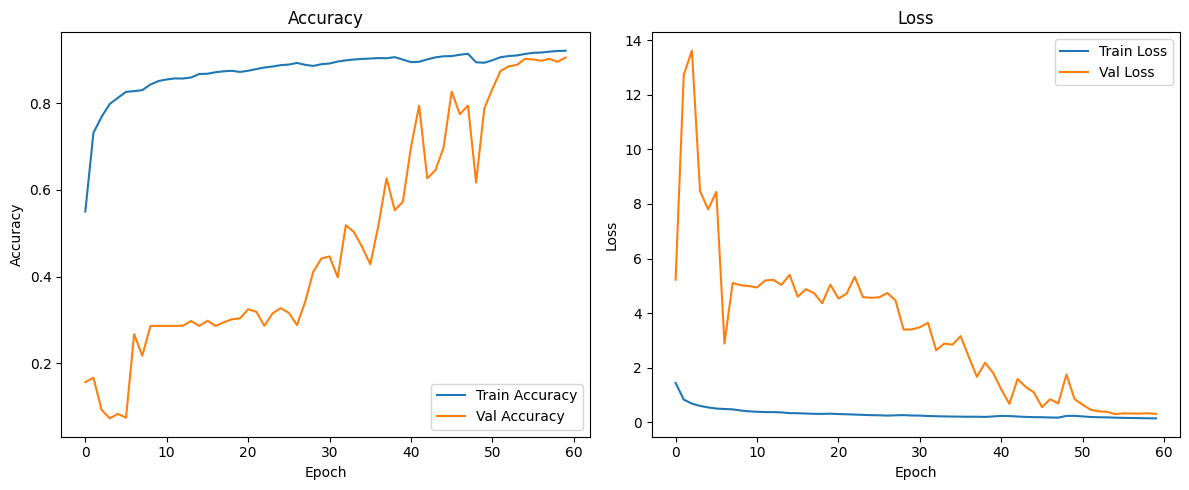

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.tight_layout()
    plt.show()

plot_history(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


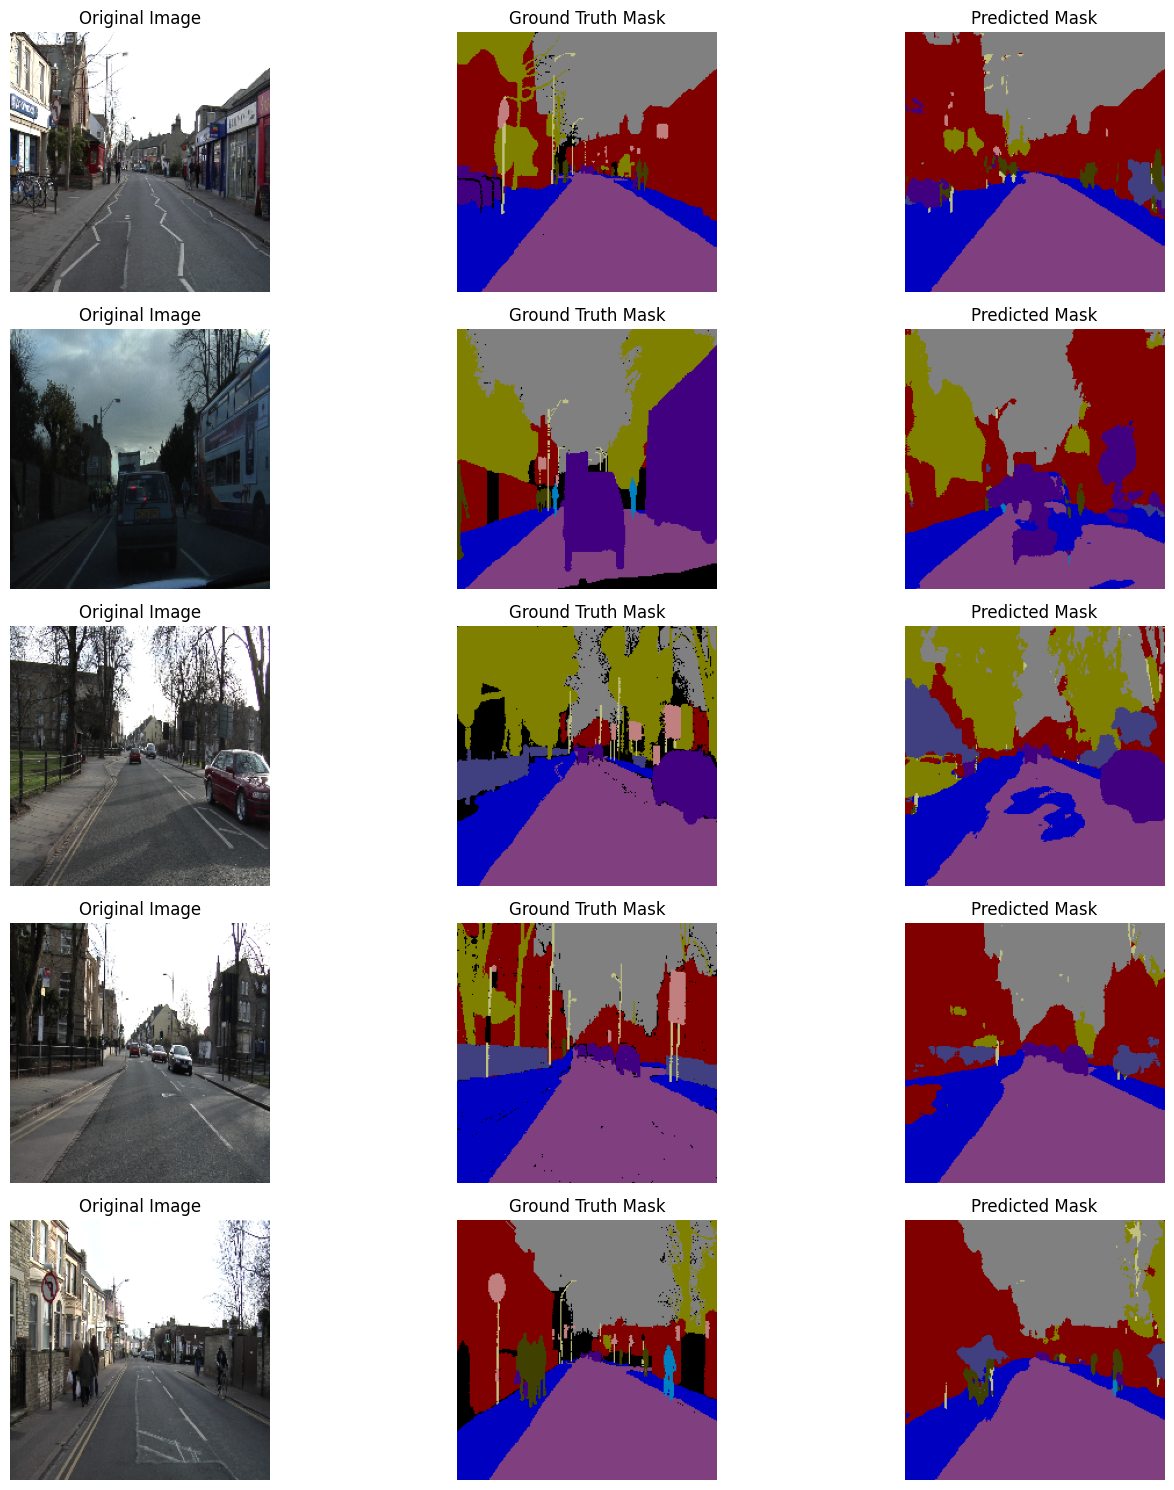

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Provided color map
color_dict = {
    0: (128, 128, 128),  # Sky
    1: (128, 0, 0),      # Building
    2: (192, 192, 128),  # Pole
    3: (128, 64, 128),   # Road
    4: (0, 0, 192),      # Sidewalk
    5: (128, 128, 0),    # Tree
    6: (192, 128, 128),  # SignSymbol
    7: (64, 64, 128),    # Fence
    8: (64, 0, 128),     # Car
    9: (64, 64, 0),      # Pedestrian
    10: (0, 128, 192),   # Bicyclist
    255: (0, 0, 0)       # Void
}

def colorize_mask(mask, color_dict):
    """Map each class ID to its corresponding RGB color."""
    mask = np.squeeze(mask)  # Ensure mask is 2D
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in color_dict.items():
        color_mask[mask == class_id] = color
    return color_mask


def visualize_predictions(model, test_images, test_masks, num_samples=5):
    """
    Show original image, ground truth mask, and predicted mask.
    """
    indices = random.sample(range(len(test_images)), num_samples)
    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        image = test_images[idx]
        true_mask = test_masks[idx]

        # Predict mask
        pred = model.predict(image[np.newaxis, ...])[0]
        pred_mask = tf.argmax(pred, axis=-1).numpy().astype(np.uint8)

        # Colorize masks
        true_mask_colored = colorize_mask(true_mask, color_dict)
        pred_mask_colored = colorize_mask(pred_mask, color_dict)



        # Plot original image
        plt.subplot(num_samples, 3, i * 3 + 1)

        img_display = image
        if img_display.shape[-1] == 1:
            img_display = np.squeeze(img_display, axis=-1)
        if img_display.max() <= 1.0:  # likely normalized
            img_display = np.clip(img_display, 0, 1)
        else:
            img_display = img_display.astype(np.uint8)

        plt.imshow(img_display)
        plt.title("Original Image")
        plt.axis("off")



        # Plot ground truth mask
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_mask_colored)
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Plot predicted mask
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask_colored)
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the visualization function
visualize_predictions(unet_model, test_images, test_masks, num_samples=5)
